
## ver1
1.除了bo优化器外，所有设置与random-search-25-times, StandardBO-25-times中保持一致

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import time
import shutil
import pathlib
import itertools
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
import tensorflow_probability as tfp # TensorFlow Probability 的分布模块
tfd = tfp.distributions

#导入深度学习架构
from tensorflow import keras
from keras import models, optimizers, metrics, layers, regularizers, losses
from keras.models import Sequential
from keras.optimizers import SGD, RMSprop, Adam, Adagrad
import json

def set_reproducibility(seed=88):
    """
    设置全局种子来确保整个实验流程的可复现性。
    这包括Python内置random、os、NumPy和TensorFlow。
    """
    # Python 内置的 random 模块的种子
    random.seed(seed)
    
    # os 环境变量 PYTHONHASHSEED
    # 这可以防止hash碰撞，使得字典等hash操作在不同运行间保持一致
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # NumPy 的随机种子,考虑到数据预处理和初始化依赖于NumPy
    np.random.seed(seed)
    
    # TensorFlow 的全局随机种子，控制模型权重初始化、Dropout、随机数据增强等
    tf.random.set_seed(seed)
    
    # 强制 TensorFlow 使用确定性的、单线程的操作
    tf.config.experimental.enable_op_determinism()
    
    print(f"全局随机种子已设置为: {seed}，并已启用TensorFlow确定性操作。")

SEED_VALUE = 88 
set_reproducibility(SEED_VALUE)

2025-09-23 09:00:33.517402: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758618033.729306      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758618033.790112      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ 全局随机种子已设置为: 88，并已启用TensorFlow确定性操作。


In [ ]:
# kaggle中数据集会自动解压缩，只需要直接讲数据加载到output中

import matplotlib.image as img

'''加载到output路径并划分文件夹'''
!pip install split-folders -q
import splitfolders
input_dir="/kaggle/input/augmented-alzheimer-data/augmented_data"
output_dir="./output"
splitfolders.ratio(
    input_dir, 
    output=output_dir, 
    seed=1345, 
    ratio=(.70, 0.15,0.15),
    group_prefix=None #保持原始目录结构分层分割，确保每个类别都按相同比例分割
) 
print("Dataset split completed!")

#验证输出路径文件夹文件数量
def count_files(directory):
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(directory, split)
        print(f"\n{split.upper()} set:")
        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)
            num_files = len(os.listdir(class_path))
            print(f"  {class_name}: {num_files} images")

count_files("./output")

AUTOTUNE = tf.data.AUTOTUNE

IMG_HEIGHT = 224
IMG_WIDTH = 224 
batch_size=32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./output/train",
seed=123,
label_mode='int',
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=batch_size,
shuffle=True
).prefetch(buffer_size=AUTOTUNE)
# label_mode='int'后续匹配sparse_categorical_crossentropy,需设置from_logits=True/False


test_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./output/test",
label_mode='int',
seed=123,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=batch_size,
shuffle=False  
).prefetch(buffer_size=AUTOTUNE)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./output/val",
label_mode='int',
seed=123,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=batch_size,
shuffle=False
).prefetch(buffer_size=AUTOTUNE)

Copying files: 12800 files [01:54, 111.88 files/s]


Dataset split completed!

TRAIN set:
  VeryMildDemented: 2240 images
  NonDemented: 2240 images
  MildDemented: 2240 images
  ModerateDemented: 2240 images

VAL set:
  VeryMildDemented: 480 images
  NonDemented: 480 images
  MildDemented: 480 images
  ModerateDemented: 480 images

TEST set:
  VeryMildDemented: 480 images
  NonDemented: 480 images
  MildDemented: 480 images
  ModerateDemented: 480 images
Found 8960 files belonging to 4 classes.


I0000 00:00:1758618171.192770      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1758618171.193640      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1920 files belonging to 4 classes.
Found 1920 files belonging to 4 classes.


In [ ]:
import os, random, time, gc, json
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import tensorflow as tf, tensorflow_probability as tfp
from tensorflow import keras
from keras import layers, regularizers
import scipy.stats as stats
tfd = tfp.distributions
sns.set_style('whitegrid')
tf.keras.backend.set_floatx('float64')

#-----------------------------模型架构搭建：顺序模型------------------------------
def build_pretrained_model(hparams):
    # 加载预训练的EfficientNet，不包含顶部的分类层
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights='imagenet'
    )
    # 冻结预训练模型的权重
    base_model.trainable = False
    
    # 确定从哪个块开始解冻（微调）
    fine_tune_at_block = 'block5a_expand_conv'
    
    # 遍历所有层，解冻 fine_tune_at_block 及之后的所有层
    set_trainable = False
    for layer in base_model.layers:
        if layer.name == fine_tune_at_block:
            set_trainable = True
        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False

    # 无论是否解冻，都保持 BatchNormalization冻结
    # 在微调时，如果用小批量数据更新BN层的统计数据可能会引入噪声，破坏预训练学到的分布
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    
    dense_units = int(hparams.get('dense_units', 128))
    dropout_rate = hparams.get('dropout_rate', 0.5)
    l2_reg = hparams.get('l2_reg', 0.001)
    lr = hparams.get('lr', 0.0001)
    optimizer_choice = int(hparams.get('optimizer_choice', 0))
    momentum = hparams.get('momentum', 0.9)
    
    # 在预训练模型之上，构建一个分类头
    model = tf.keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(), # 使用全局平均池化替代Flatten，参数更少，不易过拟合
        layers.Dense(dense_units, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)), # 使用更小的L2值
        layers.Dropout(dropout_rate),
        layers.Dense(4, activation='softmax') # 4个类别
    ])

    if optimizer_choice == 0:
        print("--- 使用 Adam 优化器 ---")
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_choice == 1:
        print(f"--- 使用 SGD 优化器 (momentum={momentum:.3f}) ---")
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=momentum)
    elif optimizer_choice == 2:
        print("--- 使用 RMSprop 优化器 ---")
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else: # optimizer_choice == 3
        print("--- 使用 Adagrad 优化器 ---")
        optimizer = tf.keras.optimizers.Adagrad(learning_rate=lr)

    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
   
    return model


## 自定义回调类
class TrainingCallback(keras.callbacks.Callback):
    def __init__(self, epochs):
        super().__init__()
        self.epochs = epochs
    def on_train_begin(self, logs=None):
        header = "{0:^8s}{1:^11s}{2:^11s}{3:^12s}{4:^12s}{5:^12s}".format('Epoch', 'Loss', 'Acc', 'Val_Loss', 'Val_Acc', 'Duration')
        print(header)
    def on_epoch_begin(self, epoch, logs=None): 
        self.ep_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        duration = time.time() - self.ep_start
        acc = logs.get('accuracy', 0); val_acc = logs.get('val_accuracy', 0)
        loss = logs.get('loss', 0); val_loss = logs.get('val_loss', 0)
        msg = f'{str(epoch + 1):^3s}/{str(self.epochs):4s} {loss:^10.3f}{acc * 100:^11.3f}{val_loss:^12.5f}{val_acc * 100:^12.3f}{duration:^12.2f}'
        print(msg)
        

## 超参数的评估函数
def train_and_evaluate_model(hparams,train_ds,val_ds,epochs=30):
    #创建模型
    model = build_pretrained_model(hparams) 
    
    training_callback = TrainingCallback(
        epochs=epochs
    )
    # 加入早停回调 
    early_stopping_callback = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,  # 验证集准确率连续5个epoch没有提升就停止
        min_delta=0.005,
        restore_best_weights=True, # 关键：自动恢复到性能最好的那个epoch的权重
        verbose=0 
    )
    
    #训练模型
    history = model.fit(
        train_ds,
         #验证数据集(可选参数)在每个epoch结束后，模型会在这个数据集上评估性能
        validation_data=val_ds,
        epochs=epochs,
        verbose=0,
        callbacks=[training_callback,early_stopping_callback]
    )

    # 返回验证集准确率（贝叶斯优化会最大化此值）
    loss, accuracy = model.evaluate(val_ds, verbose=0)
    # 从早停回调中获取最佳轮次信息
    best_epoch_num = early_stopping_callback.best_epoch + 1
    print(f"  > 训练评估完成: Best Val Acc: {accuracy:.4f}, 对应的 Loss:{loss:.4f}(at epoch {best_epoch_num})")
    
    return accuracy

In [ ]:
# 自定义贝叶斯优化器
class BayesianOptimizer:
    def __init__(self, search_space, init_points=5, exploration=0.01, 
                 log_file="custom_bo_log.json", initial_X=None, initial_y=None):
        self.search_space = np.array(search_space)
        self.dim = len(search_space)
        self.init_points = init_points
        self.exploration = exploration
        self.log_file = log_file
        # 以防训练由于超时中断,设置自断点处接着BO迭代,加载已计算好的数据
        if initial_X is not None and initial_y is not None:
            self.X_obs = initial_X
            self.y_obs = initial_y
            print(f"BO optimizer has used {len(self.y_obs)} observed datas to initialize")
            #日志回填
            print(f"new log '{self.log_file}' is set and loads old data into it ")
            if os.path.exists(self.log_file):
                os.remove(self.log_file)
            for i in range(len(self.y_obs)):
                self._write_log(iteration=i + 1, x_new=self.X_obs[i], y_new=self.y_obs[i])
            print(f"历史数据回填完成。共写入 {len(self.y_obs)} 条记录。")
        else: 
            self.X_obs = np.zeros((0, self.dim))
            self.y_obs = np.zeros(0)
            if os.path.exists(self.log_file):
                os.remove(self.log_file)
                
        self.theta_dim = self.dim + 2 # length_scales (dim) + amplitude + noise
        
        self.num_samples = 20
        self.burn_in = 100
        

    def random_sample(self):
        """在搜索空间内随机采样一个超参数点。"""
        return np.array([np.random.uniform(low, high) for (low, high) in self.search_space])

    @tf.function(jit_compile=True) # 使用XLA编译加速
    def matern52_kernel(self, X1, X2, theta):
        X1_tf = tf.cast(X1, tf.float64)
        X2_tf = tf.cast(X2, tf.float64)
        theta = tf.cast(theta, tf.float64)
        
        length_scales = theta[:self.dim]
        amplitude = theta[self.dim]
        
        X1_scaled = X1_tf / length_scales
        X2_scaled = X2_tf / length_scales

        # 使用广播机制
        r2 = tf.reduce_sum(tf.square(X1_scaled), axis=1, keepdims=True) - 2 * tf.matmul(X1_scaled, X2_scaled, transpose_b=True) + tf.reduce_sum(tf.square(X2_scaled), axis=1)
        # 确保 r2 不为负数
        r2 = tf.maximum(r2, 1e-12)
        r = tf.sqrt(r2)
        
        # 将所有Python字面量常数转换为tf.float64类型的张量
        # tf对张量计算的dtype非常严格,必须保持张量类型一样才能计算
        # python原生数据类型没关系,可以和任意张量类型计算
        five_64 = tf.constant(5.0, dtype=tf.float64)
        three_64 = tf.constant(3.0, dtype=tf.float64)
        one_64 = tf.constant(1.0, dtype=tf.float64)
        sqrt5_64 = tf.sqrt(five_64)
        
        term = (one_64 + sqrt5_64 * r + (five_64 / three_64) * r2) * tf.exp(-sqrt5_64 * r)
        
        K = amplitude**2 * term
        return K

    
    @tf.function(jit_compile=True) 
    def log_posterior(self, theta, X, y):
        f64 = tf.constant(1e-6, dtype=tf.float64)
        two_pi_64 = tf.constant(2.0 * np.pi, dtype=tf.float64)
        half_64 = tf.constant(0.5, dtype=tf.float64)
        
        # 将输入确保为 float64
        X_tf = tf.cast(X, dtype=tf.float64)
        y_tf = tf.cast(y, dtype=tf.float64)
        theta_tf = tf.cast(theta, dtype=tf.float64)
        
        noise = theta_tf[self.dim + 1]**2
        
        K = self.matern52_kernel(X_tf, X_tf, theta_tf)
        n = tf.shape(K)[0]
        K += (noise + f64) * tf.eye(n, dtype=tf.float64)
        
        L = tf.linalg.cholesky(K)
        alpha = tf.linalg.cholesky_solve(L, tf.expand_dims(y_tf, 1))
        
        log_lik = -half_64 * tf.squeeze(tf.matmul(tf.expand_dims(y_tf, 0), alpha))
        log_lik -= tf.reduce_sum(tf.math.log(tf.linalg.diag_part(L)))
        n_64 = tf.cast(n, tf.float64)
        log_lik -= half_64 * n_64 * tf.math.log(two_pi_64)
        
        return log_lik


    def sample_theta_posterior(self):
        def target_log_prob_fn(theta):
            return self.log_posterior(theta, self.X_obs, self.y_obs)

        kernel = tfp.mcmc.HamiltonianMonteCarlo(
            target_log_prob_fn=target_log_prob_fn,
            num_leapfrog_steps=3,
            step_size=0.1)
        
        samples = tfp.mcmc.sample_chain(
            num_results=self.num_samples,
            current_state=tf.ones(self.theta_dim, dtype=tf.float64),
            kernel=kernel,
            num_burnin_steps=self.burn_in,
            trace_fn=None)
        
        return samples.numpy()
    
    def expected_improvement(self, x_candidate, theta_samples):
        if self.y_obs.size == 0: return 1.0
        
        y_best = np.max(self.y_obs)
        x_candidate_reshaped = x_candidate.reshape(1, -1)
        
        ei_values = []
        for theta in theta_samples:

            try:
                # 将theta转为numpy，因为下面的计算在numpy中进行
                theta_np = theta.numpy() if hasattr(theta, 'numpy') else theta
                
                K_obs = self.matern52_kernel(self.X_obs, self.X_obs, theta_np).numpy()
                noise = theta_np[self.dim + 1]**2
                K_obs += (noise + 1e-6) * np.eye(len(self.X_obs))
                
                K_cross = self.matern52_kernel(self.X_obs, x_candidate_reshaped, theta_np).numpy()
                K_candidate = self.matern52_kernel(x_candidate_reshaped, x_candidate_reshaped, theta_np).numpy()
                L = np.linalg.cholesky(K_obs)
                L_inv_K_cross = np.linalg.solve(L, K_cross)
                
                mu = np.dot(L_inv_K_cross.T, np.linalg.solve(L, self.y_obs))
                sigma2 = K_candidate - np.dot(L_inv_K_cross.T, L_inv_K_cross)

                # 将 mu 和 sigma2 转换为标量
                # mu 是 (1,) 形状的一维数组, 用 [0] 提取
                mu_scalar = mu[0]
                # sigma2 是 (1,1) 形状的二维数组, 用 [0,0] 提取
                sigma2_scalar = sigma2[0, 0]
                
                sigma = np.sqrt(np.maximum(sigma2_scalar, 1e-9))
                # 如果 sigma 过小，则此点没有不确定性，EI为0
                if sigma == 0.0:
                    continue

                z = (mu_scalar - y_best - self.exploration) / sigma
                
                norm = stats.norm(loc=0, scale=1)
                ei = (mu_scalar - y_best - self.exploration) * norm.cdf(z) + sigma * norm.pdf(z)
                
                # 确保 ei 是一个正常的浮点数
                if not np.isnan(ei):
                    ei_values.append(ei)

            except np.linalg.LinAlgError:
                # 矩阵计算出错时跳过此样本
                print("警告: 在EI计算中发生矩阵奇异值错误，跳过此theta样本。")
                continue
                
        return np.mean(ei_values) if ei_values else 0.0
         

    def _write_log(self, iteration, x_new, y_new):
        param_names = ['lr','dense_units','dropout_rate','l2_reg','optimizer_choice','momentum']
        params_dict = {name:val for name, val in zip(param_names, x_new)}
        log_entry={'iteration':int(iteration),
                   'accuracy':float(y_new),
                   'params':params_dict}
        with open(self.log_file,'a') as f: 
            f.write(json.dumps(log_entry)+'\n')
    

    def optimize(self, objective_fn, n_iter=30):
        #检查是 初次BO 还是 接续BO
        num_existing_points=self.X_obs.shape[0]
        num_init_points_to_run = max(0, self.init_points - num_existing_points)

        if num_init_points_to_run > 0:
            # if加载的点数少于要求的初始随机化点数，需要补充运行
            print(f"--- 继续随机初始化阶段: 还需要运行 {num_init_points_to_run} 个初始点。 ---")
            for i in range(num_init_points_to_run):
                print(f"\n--- 初始点 {num_existing_points + i + 1}/{self.init_points} ---")
                x_new = self.random_sample()
                y_new = objective_fn(x_new)
                self.X_obs = np.vstack([self.X_obs, x_new])
                self.y_obs = np.append(self.y_obs, y_new)
                self._write_log(iteration=num_existing_points + i + 1, x_new=x_new, y_new=y_new)
        
        elif num_existing_points > 0:
            # if成功恢复运行。加载的点数已满足要求，跳过随机搜索。
            print(f"--- 成功恢复优化: 已加载 {num_existing_points} 个点。跳过 {self.init_points} 个初始点的随机搜索阶段。 ---")
        
        else:
            # if全新运行 (没有加载任何数据)
            print(f"--- 开始全新运行: 执行 {self.init_points} 个初始随机点 ---")
            for i in range(self.init_points):
                print(f"\n--- 初始点 {i + 1}/{self.init_points} ---")
                x_new = self.random_sample()
                y_new = objective_fn(x_new)
                self.X_obs = np.vstack([self.X_obs, x_new])
                self.y_obs = np.append(self.y_obs, y_new)
                self._write_log(iteration=i + 1, x_new=x_new, y_new=y_new)

        print(f"\n--- 开始执行 {n_iter} 次新的贝叶斯优化迭代 ---")

        for i in range(n_iter):
            print(f"\n--- 优化迭代 {i+1}/{n_iter} ---")
            theta_samples = self.sample_theta_posterior()
            
            best_ei = -1
            best_x = None
            for _ in range(200): # 增加随机搜索次数以更好地优化采集函数
                x_candidate = self.random_sample()
                ei = self.expected_improvement(x_candidate, theta_samples)
                if ei > best_ei:
                    best_ei = ei
                    best_x = x_candidate
            
            if best_x is None:
                print("警告：无法找到有效的候选点，将进行随机采样。")
                best_x = self.random_sample()

            y_new = objective_fn(best_x)            
            self.X_obs = np.vstack([self.X_obs, best_x])
            self.y_obs = np.append(self.y_obs, y_new)
            # 在每次优化后将结果写入日志
            new_iteration_number = self.X_obs.shape[0]
            self._write_log(iteration=new_iteration_number, x_new=best_x, y_new=y_new)

        best_idx = np.argmax(self.y_obs)
        return self.X_obs[best_idx], self.y_obs[best_idx]

In [ ]:
import time
import gc 

search_space = [
    (1e-5, 5e-4),    # lr
    (64, 512),       # dense_units
    (0.2, 0.7),      # dropout_rate
    (1e-5, 5e-3),    # l2_reg
    (0, 3.99),      # 0=Adam, 1=SGD, 2=RMSprop, 3=Adagrad
    (0.85, 0.99)     # momentum
]
#=============================================================================================
def my_objective_fn(x_new):
    # 将优化器给出的numpy数组转换为超参数字典
    hparams = {
        'lr': x_new[0],
        'dense_units': int(x_new[1]),
        'dropout_rate': x_new[2],
        'l2_reg': x_new[3],
        'optimizer_choice': int(x_new[4]),
        'momentum': x_new[5],
    }
    # 清理会话并调用训练函数
    tf.keras.backend.clear_session()
    gc.collect()
    print(f"\n正在评估超参数: {hparams}")
    accuracy = train_and_evaluate_model(hparams, train_ds, val_ds, epochs=40)
    print(f"评估完成 - 验证集准确率: {accuracy:.4f}")
    return accuracy

In [ ]:
#加载日志文件,继续上次断点运行
log_file_path = "/kaggle/input/bo-data-24/continued_EI_MCMC_BO_log.json" 

param_order=['lr', 'dense_units', 'dropout_rate', 'l2_reg', 'optimizer_choice', 'momentum']
X_list = []
y_list = []
print(f"正在从已有的日志文件 '{log_file_path}' 中恢复进度...")
try:
    with open(log_file_path, 'r') as f:
        for line in f:
            line = line.strip()#去除日志每一条首尾的空白字符
            if not line: continue
            log_entry = json.loads(line)
            y_list.append(log_entry['accuracy'])
            params_dict = log_entry['params']
            X_list.append([params_dict[key] for key in param_order])

    initial_X = np.array(X_list)
    initial_y = np.array(y_list)

    print(f"✅ 成功恢复了 {len(initial_y)} 条记录。")
    print(f"   - initial_X 的形状: {initial_X.shape}")
    print(f"   - initial_y 的形状: {initial_y.shape}")

except FileNotFoundError:
    print(f"❌ 错误: 未找到日志文件，请检查路径: '{log_file_path}'")
    initial_X, initial_y = None, None

正在从已有的日志文件 '/kaggle/input/bo-data-24/continued_EI_MCMC_BO_log.json' 中恢复进度...
✅ 成功恢复了 24 条记录。
   - initial_X 的形状: (24, 6)
   - initial_y 的形状: (24,)


In [ ]:
TARGET_INIT_POINTS = 10  # 计划的初始随机点数
TARGET_BO_ITERATIONS = 20 # 计划的BO迭代总数 

#计算已完成和剩余的工作量
if initial_X is not None:
    COMPLETED_TOTAL_POINTS = len(initial_y)
    # 已完成的BO迭代次数 = 总点数 - 初始点数
    COMPLETED_BO_ITERATIONS = max(0, COMPLETED_TOTAL_POINTS - TARGET_INIT_POINTS)
    # 剩余的BO迭代次数
    REMAINING_BO_ITERATIONS = max(0, TARGET_BO_ITERATIONS - COMPLETED_BO_ITERATIONS)

    print("\n" + "="*50)
    print("恢复运行计算:")
    print(f"  - 目标初始点数: {TARGET_INIT_POINTS}")
    print(f"  - 目标BO迭代次数: {TARGET_BO_ITERATIONS}")
    print("-" * 20)
    print(f"  - 已完成总点数: {COMPLETED_TOTAL_POINTS}")
    print(f"  - 已完成BO迭代: {COMPLETED_BO_ITERATIONS}")
    print(f"  - 剩余BO迭代: {REMAINING_BO_ITERATIONS}")
    print("="*50)

    # 实例化优化器并传入上次运行历史数据
    optimizer = BayesianOptimizer(
        search_space=search_space,
        init_points=TARGET_INIT_POINTS,
        log_file="second_continued_EI_MCMC_BO_log30.json",  # 存储旧历史数据和新运行数据的文件
        initial_X=initial_X,
        initial_y=initial_y
    )

    # 运行剩余的优化迭代
    if REMAINING_BO_ITERATIONS > 0:
        print(f"\n🚀 开始继续执行剩余的 {REMAINING_BO_ITERATIONS} 次贝叶斯优化迭代...")
        #optimizer.optimize返回的是一个Numpy数组
        best_x, best_y = optimizer.optimize(
            objective_fn=my_objective_fn, 
            n_iter=REMAINING_BO_ITERATIONS # 只运行剩余的次数
        )
        print("\n🎉🎉🎉 贝叶斯优化已全部完成! 🎉🎉🎉")
        
    else:
        print("\n所有计划的迭代均已完成，无需继续运行。")

else:
    print("\n未能加载恢复数据，无法继续运行。")


# #如果是初次运行则直接运行：
# optimizer = BayesianOptimizer(search_space=search_space, 
#                               init_points=10,
#                               log_file="./EI_MCMC_BO_log.json" # 传入日志文件名
#                              )

# best_x, best_y = optimizer.optimize(objective_fn=my_objective_fn, n_iter=10)  

print("\n" + "="*50); print("贝叶斯优化完成!")
print(f"最佳验证准确率: {best_y:.4f}")

param_names = ['lr', 'dense_units', 'dropout_rate', 'l2_reg', 'optimizer_choice', 'momentum']
best_hparams = {name: val for name, val in zip(param_names, best_x)}
best_hparams['dense_units'] = int(best_hparams['dense_units'])
best_hparams['optimizer_choice'] = int(best_hparams['optimizer_choice'])

print(f"最佳超参数: {best_hparams}")
print("="*50)


恢复运行计算:
  - 目标初始点数: 10
  - 目标BO迭代次数: 20
--------------------
  - 已完成总点数: 24
  - 已完成BO迭代: 14
  - 剩余BO迭代: 6
BO optimizer has used 24 observed datas to initialize
new log 'second_continued_EI_MCMC_BO_log30.json' is set and loads old data into it 
历史数据回填完成。共写入 24 条记录。

🚀 开始继续执行剩余的 6 次贝叶斯优化迭代...
--- 成功恢复优化: 已加载 24 个点。跳过 10 个初始点的随机搜索阶段。 ---

--- 开始执行 6 次新的贝叶斯优化迭代 ---

--- 优化迭代 1/6 ---


I0000 00:00:1758618174.136354      19 service.cc:148] XLA service 0x42c53dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758618174.137218      19 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1758618174.137240      19 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1758618174.254765      19 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1758618174.617192      19 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



正在评估超参数: {'lr': 5.937843679730521e-05, 'dense_units': 294, 'dropout_rate': 0.6846338450029783, 'l2_reg': 0.002195172465372667, 'optimizer_choice': 1, 'momentum': 0.9277072263380858}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- 使用 SGD 优化器 (momentum=0.928) ---
 Epoch     Loss        Acc      Val_Loss    Val_Acc     Duration  


E0000 00:00:1758618220.334677      19 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


 1 /40     2.380     36.462     2.14467      54.427      173.08   
 2 /40     2.146     48.359     1.97490      58.542      150.92   
 3 /40     2.027     53.806     1.88975      61.615      150.69   
 4 /40     1.956     57.801     1.83727      63.021      150.68   
 5 /40     1.894     60.469     1.78949      65.417      150.67   
 6 /40     1.855     62.779     1.74975      67.552      150.68   
 7 /40     1.811     64.308     1.71848      68.750      150.71   
 8 /40     1.777     66.217     1.68954      70.260      150.69   
 9 /40     1.748     67.143     1.67057      70.833      150.70   
10 /40     1.714     69.141     1.63309      72.135      150.84   
11 /40     1.695     69.754     1.61747      72.760      150.75   
12 /40     1.672     71.161     1.59349      72.969      150.78   
13 /40     1.649     71.473     1.57758      74.219      150.78   
14 /40     1.631     72.902     1.55788      75.000      150.73   
15 /40     1.618     72.801     1.54529      75.469      150.7

...

 1 /40     1.910     58.672     1.60654      73.229      172.56   
 2 /40     1.600     72.355     1.47706      76.250      150.87   
 3 /40     1.451     76.708     1.38867      78.125      150.72   
 4 /40     1.377     78.516     1.32689      78.385      150.67   
 5 /40     1.287     80.904     1.30589      78.073      150.76   
 6 /40     1.213     82.757     1.24597      80.417      150.82   
 7 /40     1.142     84.710     1.09450      85.938      150.85   
 8 /40     1.039     88.538     1.02020      89.062      150.60   
 9 /40     1.001     88.560     1.06259      86.042      150.66   
10 /40     0.909     91.406     0.88736      92.188      150.82   
11 /40     0.862     92.310     0.82718      93.333      150.86   
12 /40     0.802     93.728     0.80081      93.698      150.65   
13 /40     0.750     94.676     0.84976      89.896      150.65   
14 /40     0.716     95.234     0.73779      93.698      150.86   
15 /40     0.670     95.982     0.70533      95.000      150.7

E0000 00:00:1758634946.055272      19 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


 1 /40     2.657     47.958     2.39312      61.719      172.15   
 2 /40     2.378     61.295     2.25469      66.510      150.97   
 3 /40     2.261     66.830     2.17035      70.469      151.10   
 4 /40     2.185     69.609     2.12279      72.292      150.97   
 5 /40     2.130     72.221     2.06369      75.156      151.01   
 6 /40     2.080     74.185     2.03429      75.781      151.17   
 7 /40     2.045     75.402     1.99185      77.969      151.00   
 8 /40     2.011     76.362     1.96617      78.542      151.09   
 9 /40     1.978     77.667     1.94287      79.167      151.01   
10 /40     1.951     78.694     1.91320      80.365      151.00   
11 /40     1.925     79.833     1.89667      80.573      151.13   
12 /40     1.899     80.703     1.87621      81.823      150.94   
13 /40     1.890     80.725     1.87169      80.729      150.88   
14 /40     1.865     81.786     1.85641      82.031      150.95   
15 /40     1.847     81.998     1.82134      83.438      150.9

E0000 00:00:1758641058.466542      19 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


 1 /40     1.455     47.288     1.21674      60.052      173.16   
 2 /40     1.207     58.650     1.09081      64.635      151.29   
 3 /40     1.109     63.694     1.02237      67.917      151.20   
 4 /40     1.045     67.143     0.97272      70.417      151.48   
 5 /40     0.996     68.895     0.94898      70.885      151.32   
 6 /40     0.963     70.658     0.90161      73.750      151.30   
 7 /40     0.936     71.741     0.88021      74.583      151.33   
 8 /40     0.908     73.080     0.86580      74.896      151.31   
 9 /40     0.883     73.795     0.84350      75.312      151.32   
10 /40     0.866     74.654     0.82798      75.781      151.43   
11 /40     0.855     75.301     0.81462      76.667      151.36   
12 /40     0.834     76.217     0.80008      77.500      151.33   
13 /40     0.820     77.076     0.79539      77.708      151.33   
14 /40     0.806     77.221     0.78813      78.177      151.28   
15 /40     0.799     77.723     0.77337      78.646      151.2

✅ Log file 'second_continued_EI_MCMC_BO_log30.json' loaded successfully! Loaded 30 evaluation records.

最终优化数据:
- 全局最优Val Accuracy:                 0.9844
- 探索阶段的最优Val Accuracy :  0.9750
- Absolute Improvement from Bayesian Opt: +0.0094 points
- Relative Improvement from Bayesian Opt: +0.96%


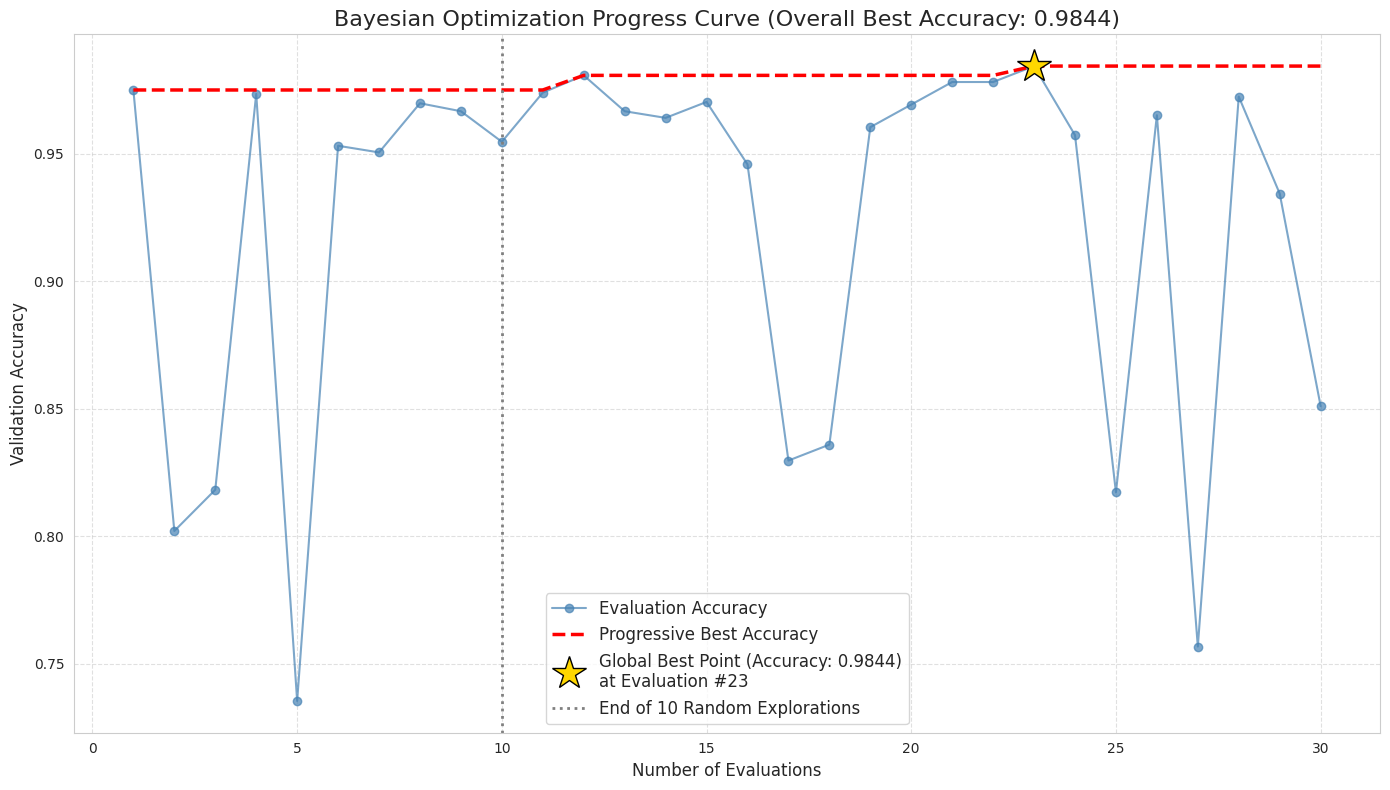

In [ ]:
# ===================================================================
# 贝叶斯优化全过程绘图
# ===================================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

log_file_path = "second_continued_EI_MCMC_BO_log30.json" 
initial_points = 10 

try:
    with open(log_file_path, 'r') as f:
        logs = [json.loads(line) for line in f]
    
    df_results = pd.DataFrame(logs)
    all_accuracies = df_results['accuracy'].values
    print(f"✅ Log file '{log_file_path}' loaded successfully! Loaded {len(all_accuracies)} evaluation records.")
    
    if len(all_accuracies) > initial_points:
        accuracies_in_init_phase = all_accuracies[:initial_points]
        best_random_accuracy = np.max(accuracies_in_init_phase)

        best_final_accuracy = np.max(all_accuracies)

        absolute_improvement = best_final_accuracy - best_random_accuracy
        
        print("\n" + "="*50)
        print("最终优化数据:")
        print("="*50)
        print(f"- 全局最优Val Accuracy: {best_final_accuracy:.4f}")
        print(f"- 探索阶段的最优Val Accuracy : {best_random_accuracy:.4f}")
        
        if best_random_accuracy > 0:
            relative_improvement = (absolute_improvement / best_random_accuracy) * 100
            print(f"- Absolute Improvement from Bayesian Opt: +{absolute_improvement:.4f} points")
            print(f"- Relative Improvement from Bayesian Opt: +{relative_improvement:.2f}%")
        else:
            print(f"- Absolute Improvement from Bayesian Opt: +{absolute_improvement:.4f} points")
        print("="*50)

    else:
        print("\nInsufficient evaluations to calculate Bayesian optimization improvement.")

    
    n_evaluations = len(all_accuracies)
    x_axis = np.arange(1, n_evaluations + 1)

    best_idx = np.argmax(all_accuracies)
    best_x = best_idx + 1
    best_y = all_accuracies[best_idx]

    plt.figure(figsize=(14, 8))
    plt.plot(x_axis, all_accuracies, 'o-', label='Evaluation Accuracy', color='steelblue', alpha=0.7)
    plt.plot(x_axis, np.maximum.accumulate(all_accuracies), 'r--', label='Progressive Best Accuracy', linewidth=2.5)
    plt.plot(best_x, best_y, 
             marker='*', 
             color='gold', 
             markersize=25, 
             markeredgecolor='black',
             linestyle='', # No connecting line
             label=f'Global Best Point (Accuracy: {best_y:.4f})\nat Evaluation #{best_x}')
    plt.axvline(initial_points, color='gray', linestyle=':', linewidth=2, label=f'End of {initial_points} Random Explorations')

    plt.xlabel('Number of Evaluations', fontsize=12)
    plt.ylabel('Validation Accuracy', fontsize=12)
    plt.title(f'Bayesian Optimization Progress Curve (Overall Best Accuracy: {best_final_accuracy:.4f})', fontsize=16)
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig('final_optimization_curve_bo.png')
    plt.show()

except FileNotFoundError:
    print(f"Error: Log file '{log_file_path}' not found. Please ensure the path is correct.")